<a href="https://colab.research.google.com/github/Saakshi-G/Data-Mining_-Labs/blob/main/CSE572_Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE 572: Lab 3

In this lab, you will practice implementing to handle imbalanced datasets. You will use methods such as upsampling, downsampling, and SMOTE to balance/augment different datasets (matrix, image, text data) and evaluate how these techniques affect model performance.

To execute and make changes to this notebook, click File > Save a copy to save your own version in your Google Drive or Github. Read the step-by-step instructions below carefully. To execute the code, click on each cell below and press the SHIFT-ENTER keys simultaneously or by clicking the Play button.

When you finish executing all code/exercises, save your notebook then download a copy (.ipynb file). Submit 1) a link to your Colab notebook, 2) the .ipynb file, and **3) a pdf of the executed notebook** on Canvas.

To generate a pdf of the notebook, click File > Print > Save as PDF.

# **PUT YOUR TEAM Member INFO and Constribution HERE**

## ASU ID: 1238037361

| NAME             | ASURITE ID | Contribution |
|------------------|------------|--------------|
| Saakshi Gupta    | sgupt477   |     100%     |

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification


In [2]:
# Step 1: Load Dataset
# Using an imbalanced dataset from scikit-learn
X, y = make_classification(n_classes=2, class_sep=2, weights=[0.9, 0.1],
                           n_informative=3, n_redundant=1, flip_y=0,
                           n_features=5, n_clusters_per_class=1,
                           n_samples=1000, random_state=42)
data = pd.DataFrame(X, columns=[f'feature{i}' for i in range(1, X.shape[1] + 1)])
data['label'] = y

print("Original Dataset Class Distribution:")
print(data['label'].value_counts())


Original Dataset Class Distribution:
label
0    900
1    100
Name: count, dtype: int64


In [3]:
# Step 2: Train-Test Split
X = data.drop('label', axis=1)
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Balancing Techniques

In [4]:
## Upsampling Minority Class
train_data = pd.concat([X_train, y_train], axis=1)
minority = train_data[train_data['label'] == 1]
majority = train_data[train_data['label'] == 0]
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
upsampled_data = pd.concat([majority, minority_upsampled])

In [5]:
print("Upsampled Dataset Class Distribution:")
# Your Code Here
print(upsampled_data['label'].value_counts())

Upsampled Dataset Class Distribution:
label
0    629
1    629
Name: count, dtype: int64


In [6]:
## Downsampling Majority Class
majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)
downsampled_data = pd.concat([majority_downsampled, minority])

In [7]:
print("Downsampled Dataset Class Distribution:")
# Your Code Here
print(downsampled_data['label'].value_counts())

Downsampled Dataset Class Distribution:
label
0    71
1    71
Name: count, dtype: int64


In [8]:
## SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)

In [9]:
print("SMOTE Dataset Class Distribution:")
# Your Code Here
print(pd.Series(y_smote).value_counts())

SMOTE Dataset Class Distribution:
label
0    629
1    629
Name: count, dtype: int64


In [10]:
# Step 4: Train Classifiers and Evaluate

## Helper function to train and evaluate a model
def train_and_evaluate(X_train, y_train, X_test, y_test, method_name):
    print(f"\nResults for {method_name}:")
    model = LogisticRegression(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

# Train and evaluate on original data
train_and_evaluate(X_train, y_train, X_test, y_test, "Original Dataset")

# Train and evaluate on upsampled data
train_and_evaluate(upsampled_data.drop('label', axis=1), upsampled_data['label'], X_test, y_test, "Upsampled Dataset")

# Train and evaluate on downsampled data
train_and_evaluate(downsampled_data.drop('label', axis=1), downsampled_data['label'], X_test, y_test, "Downsampled Dataset")

# Train and evaluate on SMOTE data
train_and_evaluate(X_smote, y_smote, X_test, y_test, "SMOTE Dataset")


Results for Original Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       271
           1       1.00      1.00      1.00        29

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
[[271   0]
 [  0  29]]

Results for Upsampled Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       271
           1       1.00      1.00      1.00        29

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
[[271   0]
 [  0  29]]

Results for Downsampled Dataset:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       271
           1       1.00      1.00      1.00        29

   

**Question 1: Analyze and compare the results from the different balancing techniques. Which method provided the best balance between precision, recall, and F1-score?**

**Answer:**

All four methods: imbalanced, upsampling, downsampling and SMOTE, had excellent performance of 1.00 for precision, recall, and F1-score for each class. Therefore, none of the balancing methods stood out in the experiment performed. This occurred due to the fact that the dataset was specially designed to have perfectly separated classes, which meant that even the imbalanced model did not need any balancing to correctly predict all test samples. When dealing with real-world data, in which classes are overlapped and difficult to separate (as in the case of HW0 dataset), the impact of imbalance is significant and where the menthods will show distinct results.


# Image Data Augmentation



## Installs

In [11]:
#@title Install Dependencies
!pip install imgaug --quiet
!pip install albumentations --quiet
!pip install torchvision --quiet
!pip install opencv-python --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 95.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.


In [12]:
!pip install "numpy<2.0" --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dm-tree 0.1.10 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.8.23 requires numpy>=2.1, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ml-dtypes 0.6.0 requires numpy>=2.1.0; python_version >= "3.13", but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.14.0.94 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy

## Env Config

In [1]:
#@title Imports
import imgaug.augmenters as iaa
import cv2
import matplotlib.pyplot as plt
import requests
import numpy as np

In [2]:
#@title Env params

IMG_PATH = 'https://www.gstatic.com/webp/gallery/1.jpg' #@param

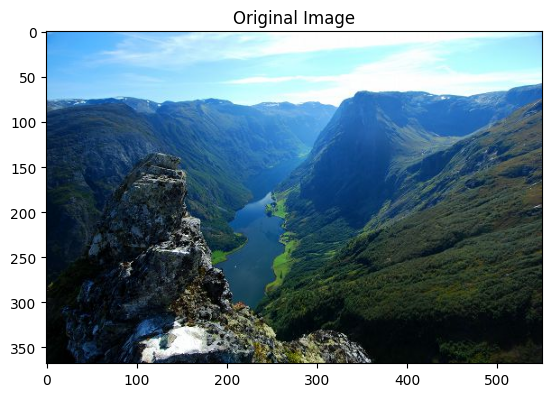

In [3]:


# Fetch the image from the URL
response = requests.get(IMG_PATH, stream=True).raw
image = np.asarray(bytearray(response.read()), dtype="uint8")
image = cv2.imdecode(image, cv2.IMREAD_COLOR)

# Convert from BGR to RGB for matplotlib
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.show()

## Image Augmentation Options

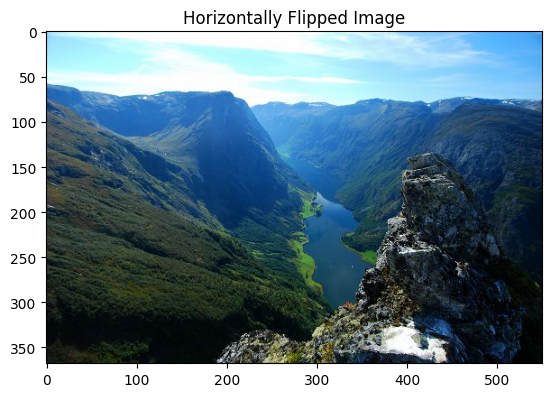

In [4]:
#@title Flipping

import imgaug.augmenters as iaa

# flip horizontally
flip_aug = iaa.Fliplr(1.0)  # 1.0 means always flip

augmented_image = flip_aug.augment_image(image)

plt.imshow(augmented_image)
plt.title("Horizontally Flipped Image")
plt.show()


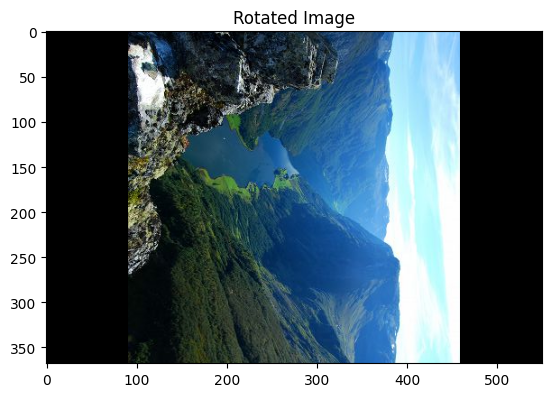

In [5]:
#@title Option 2: Rotation
rotate_aug = iaa.Affine(rotate=(90)) # rotating 90 degrees, if you pass in a tupple, rotate will pick a random value between your two params

augmented_image = rotate_aug.augment_image(image)

plt.imshow(augmented_image)
plt.title("Rotated Image")
plt.show()

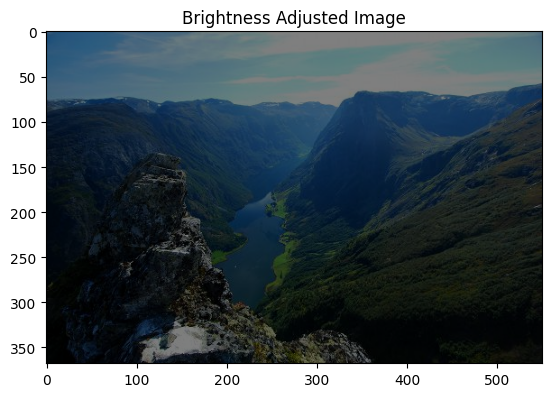

In [6]:
#@title Brightness Adjustment

brightness_aug = iaa.Multiply((0.5))

augmented_image = brightness_aug.augment_image(image)

plt.imshow(augmented_image)
plt.title("Brightness Adjusted Image")
plt.show()

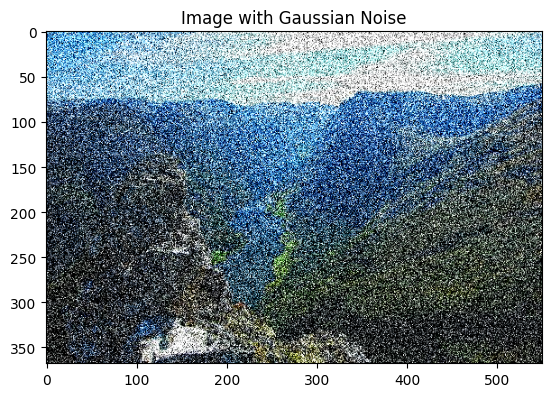

In [7]:
#@title Option 4: Random Noise

noise_aug = iaa.AdditiveGaussianNoise(scale=(100)) # standard deviation fixed at 100

augmented_image = noise_aug.augment_image(image)

plt.imshow(augmented_image)
plt.title("Image with Gaussian Noise")
plt.show()

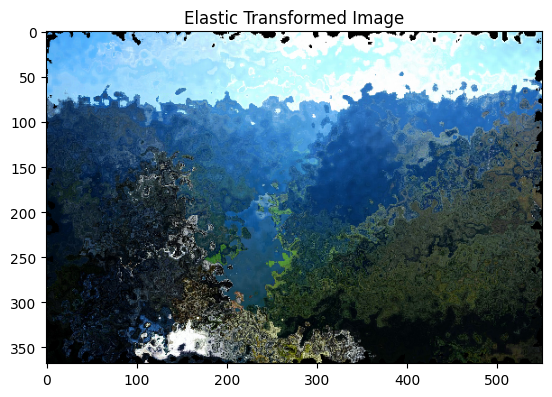

In [8]:
#@title Distortions (Elastic Transformation)

elastic_aug = iaa.ElasticTransformation(alpha=100, sigma=3) # alpha contols level of distortions, sigma controls focus on unnoticable distortions

augmented_image = elastic_aug.augment_image(image)

plt.imshow(augmented_image)
plt.title("Elastic Transformed Image")
plt.show()

# NLP Data Augmentation

## Installs

In [9]:
#@title Install Dependencies
!pip install --upgrade gensim --quiet
!pip install transformers --quiet
!pip install sacremoses --quiet
!pip install nlpaug --quiet

In [10]:
#@title Download Models
from nlpaug.util.file.download import DownloadUtil

# DownloadUtil.download_word2vec(dest_dir = '.')
# Possible values are ‘wiki-news-300d-1M’, ‘wiki-news-300d-1M-subword’, ‘crawl-300d-2M’ and ‘crawl-300d-2M-subword’

DownloadUtil.download_fasttext(dest_dir = '.', model_name = 'crawl-300d-2M')

# for synonym replacement
# DownloadUtil.download_glove(dest_dir = '.', model_name = 'glove.6B')

## Config Env

In [11]:
#@title Imports (restart runtime)
import gensim
print(gensim.__version__)

import transformers

import sacremoses # for back translation tokenizer

import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import nlpaug.flow as nafc
from nlpaug.util import Action


4.4.0


In [4]:
#@title Example Sentence for Augmentation

TEXT = "I have been riding my scooter to the store everyday to get bananas." #@param

## Options for NLP Data Augmentation

In [20]:
!pip install gdown --quiet
!gdown --id 0B7XkCwpI5KDYNlNUTTlSS21pQmM -O GoogleNews-vectors-negative300.bin.gz
!gunzip GoogleNews-vectors-negative300.bin.gz

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM
From (redirected): https://drive.google.com/uc?id=0B7XkCwpI5KDYNlNUTTlSS21pQmM&confirm=t&uuid=b6cd3fb2-01a1-4ac7-a8b1-d198655c945d
To: /content/GoogleNews-vectors-negative300.bin.gz
100% 1.65G/1.65G [00:32<00:00, 51.3MB/s]


In [21]:
#@title Option 1: Replace words with other most similar words

aug = naw.WordEmbsAug(
  model_type = "word2vec",
  model_path = "GoogleNews-vectors-negative300.bin",
  action = "substitute",  # "insert" is another option that doesn't remove og words
  aug_p = 0.25 # probability of token selection for replacement
  )

# # Other Models you can use
# aug = naw.WordEmbsAug(
#   model_type = 'fasttext',
#   model_path = 'crawl-300d-2M.vec',
#   action = "insert"
#   )

# aug = naw.WordEmbsAug(
#   model_type = 'glove',
#   model_path = 'glove.6B.300d.txt',
#   action = "substitute"
#   )


# Augment the text
augmented_text = aug.augment(TEXT)
print(f"Original:         {TEXT}\n")
print(f"Augmented Text:   {augmented_text}")

Original:         I have been riding my scooter to the store everyday to get bananas.

Augmented Text:   ['I even been riding my scooter to whole Woodland_Hills_Mall everyday to push bananas.']


In [1]:
!pip install -q numpy==2.2.2
!pip install -q transformers==4.49.0
!pip install -q nlpaug

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 21.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
diffusers 0.40.0 requires huggingface-hub<2.0,>=1.23.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import nlpaug.augmenter.word as naw

In [5]:
#@title Option 2: Add context words based on nearest embeddings

aug = naw.ContextualWordEmbsAug(
  model_path = 'bert-base-uncased',
  action = "insert",
  aug_p = 0.25
  )

augmented_text = aug.augment(TEXT)

print(f"Original:         {TEXT}\n")
print(f"Augmented Text:   {augmented_text}")

Original:         I have been riding my scooter to the store everyday to get bananas.

Augmented Text:   ['i have since been secretly riding my baby scooter to the store everyday trying to get bananas.']


In [7]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [8]:
#@title Option 3: Synonym Replacement

aug = naw.SynonymAug(
    aug_src = "wordnet",
    aug_max = 3 # aug_p words too but this allows us to limit how many words are changed
    )
augmented_text = aug.augment(TEXT)

print(f"Original:         {TEXT}\n")
print(f"Augmented Text:   {augmented_text}")

Original:         I have been riding my scooter to the store everyday to get bananas.

Augmented Text:   ['I have been ride my scooter to the store everyday to get banana tree.']


In [9]:
#@title Option 4: Translations (and back translation)

back_translation_aug = naw.BackTranslationAug(
    from_model_name = 'facebook/wmt19-en-de',
    to_model_name = 'facebook/wmt19-de-en'
)

augmented_text = back_translation_aug.augment(TEXT)

print(f"Original:         {TEXT}\n")
print(f"Augmented Text:   {augmented_text}")

config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/235 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/825 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.09G [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

vocab-src.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Original:         I have been riding my scooter to the store everyday to get bananas.

Augmented Text:   ['I used to go to the shop every day on my scooter to get bananas. I had to get the bananas, but I had to get a lot of the bananas, I had a lot of the bananas, I had a lot of the bananas, I had a lot of the bananas.']
